# Customer Churn Intelligence — SHAP Explainability

## Objective

Explain the **final selected model** from prior steps:

- **XGBoost + class weighting**
- **Sigmoid (Platt) calibration** retained in Step 17
- Business threshold **0.10** (from calibrated validation optimization)

Use **train and validation data only**. The final test set is **not used**.

**Stage:** Step 18 — SHAP explainability (no model changes, no threshold retuning, no test-set evaluation).

### Interpretation note (AGENTS.md)

SHAP values describe **how features influenced the model's prediction**, not what **caused** customer churn. Calibrated churn probabilities are shown for local cases; SHAP contributions come from the underlying tree model that feeds calibration.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier

PROJECT_ROOT = Path("..").resolve()
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
GLOBAL_IMPORTANCE_PATH = REPORTS_DIR / "shap_global_importance.csv"
LOCAL_EXPLANATIONS_PATH = REPORTS_DIR / "shap_local_explanations.json"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_split import load_split_from_manifest
from src.preprocessing import build_preprocessor, get_transformed_feature_names

RANDOM_STATE = 42
TOP_K = 5

## 1. Load Final Model (Same Configuration as Steps 15–17)

In [2]:
split = load_split_from_manifest()
X_train, X_val = split.X_train, split.X_val
y_train = (split.y_train == "Yes").astype(int)
y_val = (split.y_val == "Yes").astype(int)
id_val = split.id_val
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

preprocessor = build_preprocessor()
X_train_t = preprocessor.fit_transform(X_train)
X_val_t = preprocessor.transform(X_val)
feature_names_raw = get_transformed_feature_names(preprocessor)

xgb_params = dict(
    n_estimators=200, max_depth=3, learning_rate=0.1, subsample=0.8,
    colsample_bytree=1.0, scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=-1,
)

tree_model = XGBClassifier(**xgb_params)
tree_model.fit(X_train_t, y_train)

calibrated_model = CalibratedClassifierCV(
    XGBClassifier(**xgb_params), method="sigmoid", cv=5,
)
calibrated_model.fit(X_train_t, y_train)

val_proba = calibrated_model.predict_proba(X_val_t)[:, 1]

print(f"Train: {len(X_train):,} | Validation: {len(X_val):,}")
print(f"Validation calibrated probability mean: {val_proba.mean():.4f}")

Train: 4,930 | Validation: 1,056
Validation calibrated probability mean: 0.2729


In [3]:
def clean_feature_name(name: str) -> str:
    """Make OHE/scaler output names readable for plots and tables."""
    return name.replace("num__", "").replace("cat__", "").replace("_", " ")


feature_names = [clean_feature_name(n) for n in feature_names_raw]
X_val_df = pd.DataFrame(X_val_t, columns=feature_names)

## 2. Global SHAP — TreeExplainer on XGBoost

XGBoost is tree-based, so `shap.TreeExplainer` is appropriate. SHAP values reflect feature influence on the **tree model score**; calibrated probabilities are used separately for local churn-risk reporting.

In [4]:
explainer = shap.TreeExplainer(tree_model)
shap_values = explainer.shap_values(X_val_t)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

mean_abs_shap = np.abs(shap_values).mean(axis=0)
global_importance = (
    pd.DataFrame({"Feature": feature_names, "Mean_Abs_SHAP": mean_abs_shap})
    .sort_values("Mean_Abs_SHAP", ascending=False)
    .reset_index(drop=True)
)
global_importance["Rank"] = global_importance.index + 1
global_importance.to_csv(GLOBAL_IMPORTANCE_PATH, index=False)

print(f"Saved: {GLOBAL_IMPORTANCE_PATH}")
global_importance.head(10)

Saved: D:\SE Study\Data Science\ML Projects for Portfolio\customer-churn-intelligence\reports\shap_global_importance.csv


,Feature,Mean_Abs_SHAP,Rank
0,Contract Month-to-month,0.707437,1
1,tenure,0.497761,2
2,MonthlyCharges,0.297497,3
3,OnlineSecurity No,0.250953,4
4,TotalCharges,0.209852,5
5,InternetService Fiber optic,0.202227,6
6,TechSupport No,0.175495,7
7,PaymentMethod Electronic check,0.167934,8
8,PaperlessBilling No,0.146767,9
9,MultipleLines No,0.130978,10


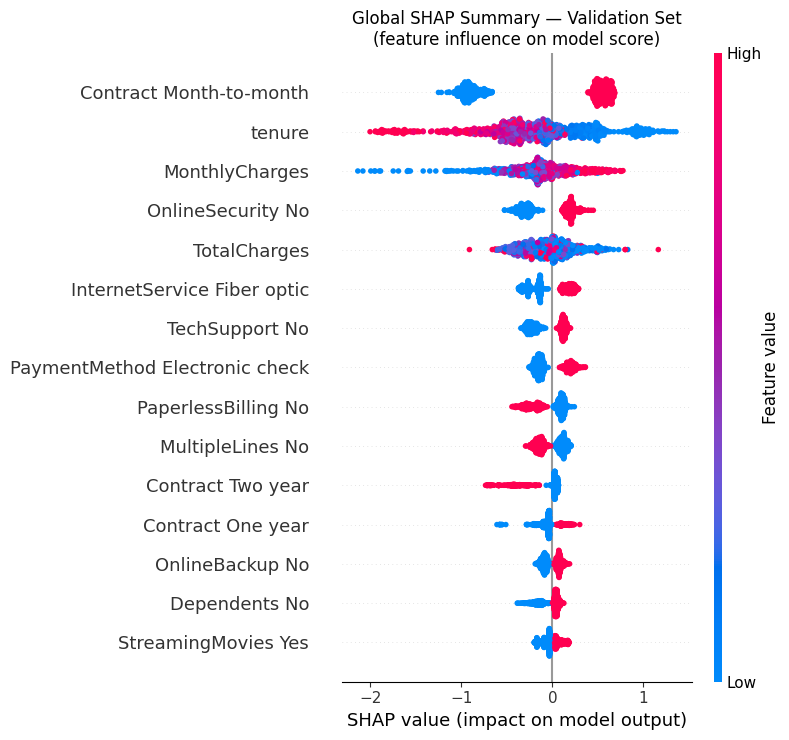

In [5]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_val_df, show=False, max_display=15)
plt.title("Global SHAP Summary — Validation Set\n(feature influence on model score)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "12_shap_summary.png", dpi=120, bbox_inches="tight")
plt.show()

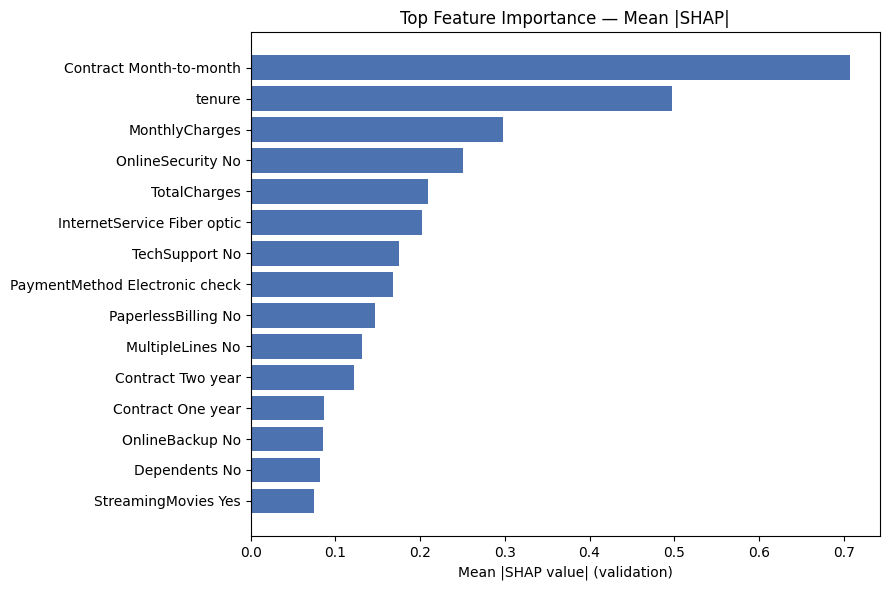

In [6]:
top_n = 15
top_features = global_importance.head(top_n)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_features["Feature"][::-1], top_features["Mean_Abs_SHAP"][::-1], color="#4C72B0")
ax.set_xlabel("Mean |SHAP value| (validation)")
ax.set_title("Top Feature Importance — Mean |SHAP|")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "13_shap_importance.png", dpi=120)
plt.show()

## 3. Local Explanations (Validation Customers)

Select three validation customers with different calibrated risk levels. For each, report:

- Calibrated churn probability
- Top features that **increased** predicted risk (positive SHAP)
- Top features that **decreased** predicted risk (negative SHAP)

Language reflects **model influence**, not causal churn drivers.

In [7]:
def local_explanation(idx: int) -> dict:
    contrib = pd.Series(shap_values[idx], index=feature_names)
    increasing = contrib.sort_values(ascending=False).head(TOP_K)
    decreasing = contrib.sort_values(ascending=True).head(TOP_K)
    actual = "Yes" if y_val.iloc[idx] else "No"
    return {
        "customerID": str(id_val.iloc[idx]),
        "validation_index": int(idx),
        "actual_churn": actual,
        "calibrated_churn_probability": round(float(val_proba[idx]), 4),
        "top_features_increasing_risk": [
            {"feature": f, "shap_value": round(float(v), 4)}
            for f, v in increasing.items()
        ],
        "top_features_decreasing_risk": [
            {"feature": f, "shap_value": round(float(v), 4)}
            for f, v in decreasing.items()
        ],
        "interpretation_note": (
            "SHAP values describe how features influenced the model prediction, "
            "not what caused churn."
        ),
    }


high_risk_idx = int(np.argmax(val_proba))
low_risk_idx = int(np.argmin(val_proba))
mid_risk_idx = int(np.argmin(np.abs(val_proba - 0.10)))

local_cases = [
    ("high_risk", high_risk_idx),
    ("low_risk", low_risk_idx),
    ("near_threshold", mid_risk_idx),
]

local_payload = {
    label: local_explanation(idx) for label, idx in local_cases
}
LOCAL_EXPLANATIONS_PATH.write_text(json.dumps(local_payload, indent=2), encoding="utf-8")
print(f"Saved: {LOCAL_EXPLANATIONS_PATH}")

for label, idx in local_cases:
    exp = local_payload[label]
    print(f"\n=== {label.replace('_', ' ').title()} — {exp['customerID']} ===")
    print(f"Actual churn: {exp['actual_churn']} | Calibrated probability: {exp['calibrated_churn_probability']}")
    print("Top features increasing risk:")
    for row in exp["top_features_increasing_risk"]:
        print(f"  + {row['feature']}: {row['shap_value']}")
    print("Top features decreasing risk:")
    for row in exp["top_features_decreasing_risk"]:
        print(f"  - {row['feature']}: {row['shap_value']}")

Saved: D:\SE Study\Data Science\ML Projects for Portfolio\customer-churn-intelligence\reports\shap_local_explanations.json

=== High Risk — 1069-XAIEM ===
Actual churn: Yes | Calibrated probability: 0.7758
Top features increasing risk:
  + tenure: 0.9767
  + Contract Month-to-month: 0.6668
  + TotalCharges: 0.3529
  + MonthlyCharges: 0.2561
  + OnlineSecurity No: 0.2284
Top features decreasing risk:
  - Contract One year: -0.044
  - StreamingTV No: -0.0314
  - PaymentMethod Mailed check: -0.0286
  - StreamingTV Yes: -0.0272
  - DeviceProtection Yes: -0.0043

=== Low Risk — 5787-KXGIY ===
Actual churn: No | Calibrated probability: 0.0362
Top features increasing risk:
  + gender Female: 0.0977
  + Partner No: 0.0439
  + StreamingMovies No: 0.023
  + Dependents No: 0.0222
  + DeviceProtection Yes: 0.0128
Top features decreasing risk:
  - MonthlyCharges: -1.5863
  - tenure: -1.4203
  - Contract Month-to-month: -0.984
  - OnlineSecurity No: -0.353
  - PaymentMethod Credit card (automatic): 

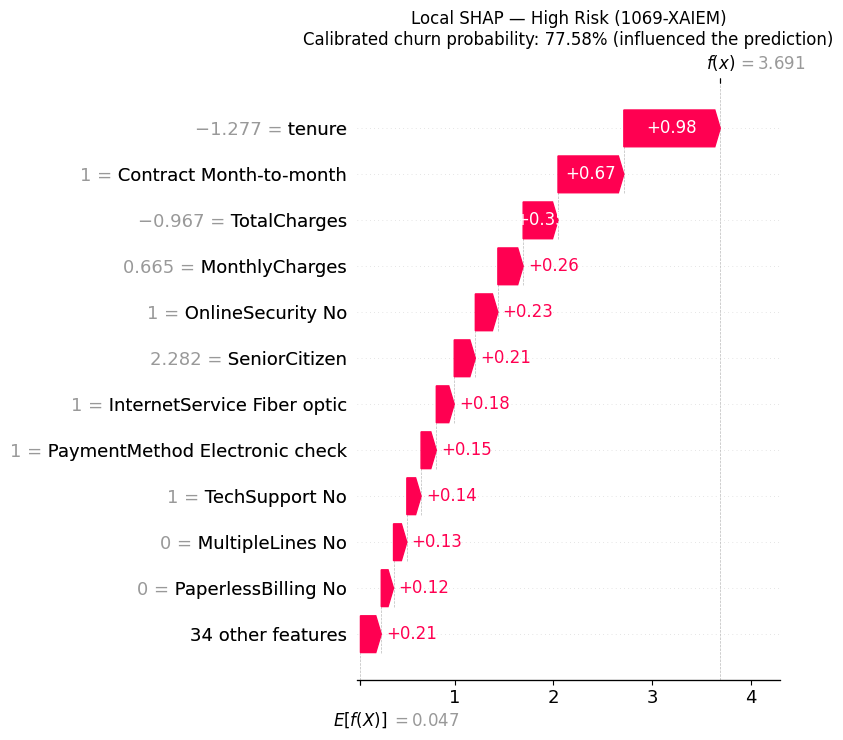

Saved: D:\SE Study\Data Science\ML Projects for Portfolio\customer-churn-intelligence\reports\figures\14_shap_local_high_risk.png


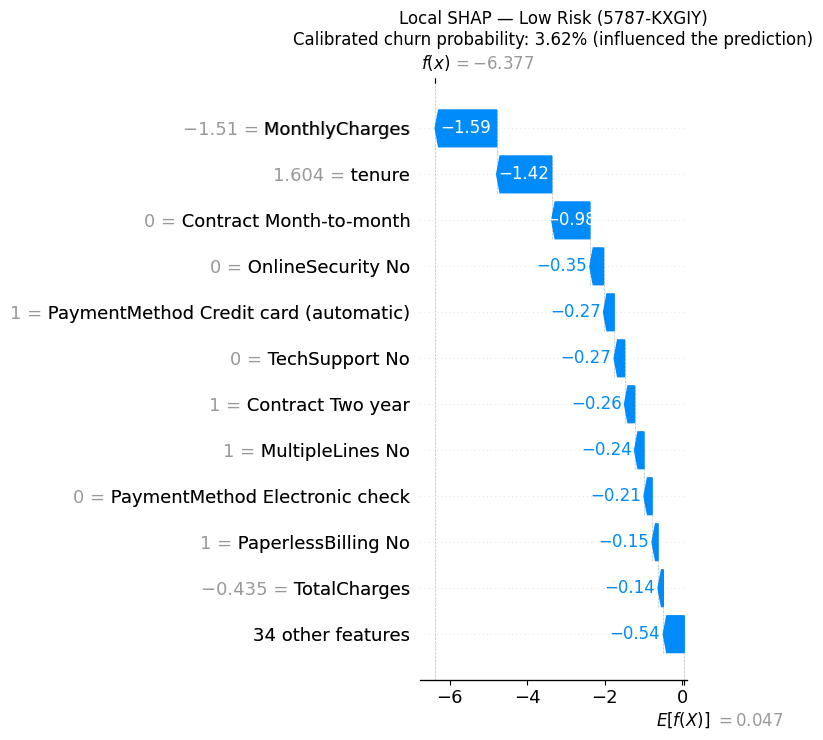

Saved: D:\SE Study\Data Science\ML Projects for Portfolio\customer-churn-intelligence\reports\figures\14_shap_local_low_risk.png


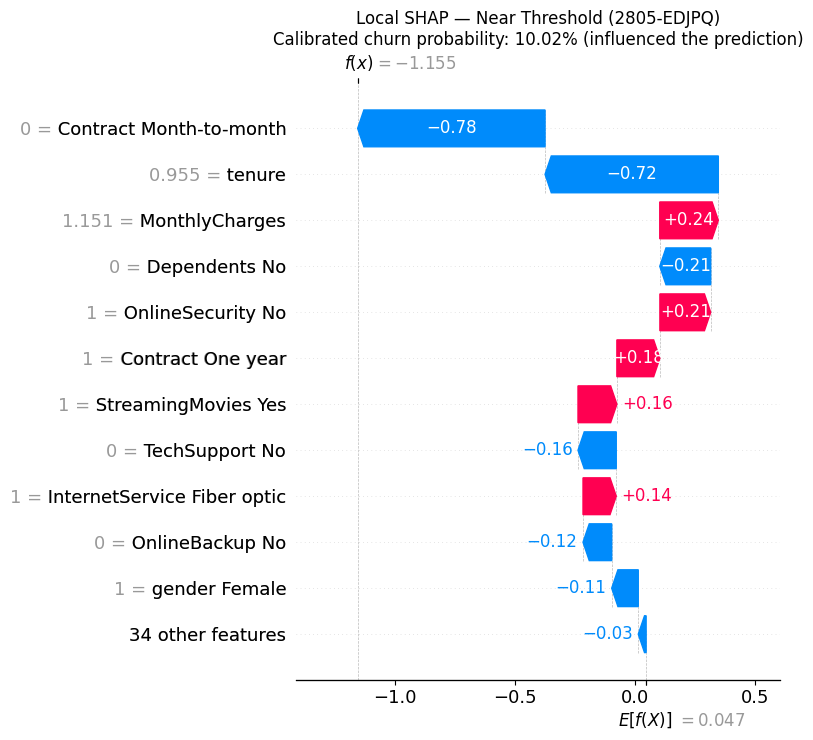

Saved: D:\SE Study\Data Science\ML Projects for Portfolio\customer-churn-intelligence\reports\figures\14_shap_local_near_threshold.png


In [8]:
for label, idx in local_cases:
    exp = shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value if not isinstance(explainer.expected_value, list) else explainer.expected_value[1],
        data=X_val_df.iloc[idx].values,
        feature_names=feature_names,
    )
    plt.figure(figsize=(9, 5))
    shap.plots.waterfall(exp, max_display=12, show=False)
    cid = local_payload[label]["customerID"]
    prob = local_payload[label]["calibrated_churn_probability"]
    plt.title(
        f"Local SHAP — {label.replace('_', ' ').title()} ({cid})\n"
        f"Calibrated churn probability: {prob:.2%} (influenced the prediction)"
    )
    plt.tight_layout()
    fig_path = FIGURES_DIR / f"14_shap_local_{label}.png"
    plt.savefig(fig_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fig_path}")

## 4. Summary

- **Global:** Mean |SHAP| ranks show which encoded features most influenced model scores across validation customers.
- **Local:** Waterfall plots and JSON summaries highlight customer-specific drivers of the **model prediction**.
- **Not causal:** Contract type, tenure, etc. may correlate with churn; SHAP only quantifies their influence on this model's output.
- **Test set:** Not used in this step.